In [54]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import QTable
import astropy.units as u
from scipy.stats import linregress

In [55]:
# open table from saved file
cal_table = QTable.read("calibration_table_large.fits")

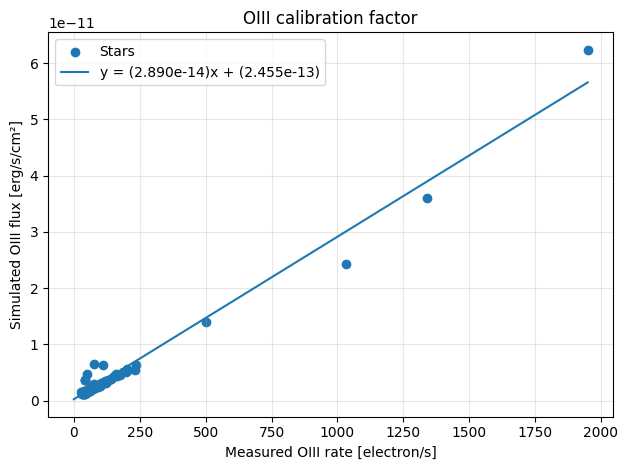

Slope: 2.890e-14
Intercept: 2.455e-13
R²: 0.9744


In [56]:
# (simulated_flux = m * measured_rate + intercept)

x = cal_table["oiii_rate"].value
y = cal_table["simulated_oiii_flux"].value

# mask invalid values
mask = (np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0))
x = x[mask]
y = y[mask]

# get line of best fit
m, b = np.polyfit(x, y, 1)

# line of best fit
x_line = np.linspace(0, x.max(), 200)
y_line = m * x_line + b

plt.scatter(x, y, label="Stars")
plt.plot(x_line, y_line, label=(f"y = ({m:.3e})x + ({b:.3e})"))

plt.xlabel("Measured OIII rate [electron/s]")
plt.ylabel("Simulated OIII flux [erg/s/cm²]")
plt.title("OIII calibration factor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# check how linear the relationship is
result = linregress(x, y)
m = result.slope
b = result.intercept
r_squared = result.rvalue**2

print(f"Slope: {m:.3e}")
print(f"Intercept: {b:.3e}")
print(f"R²: {r_squared:.4f}")

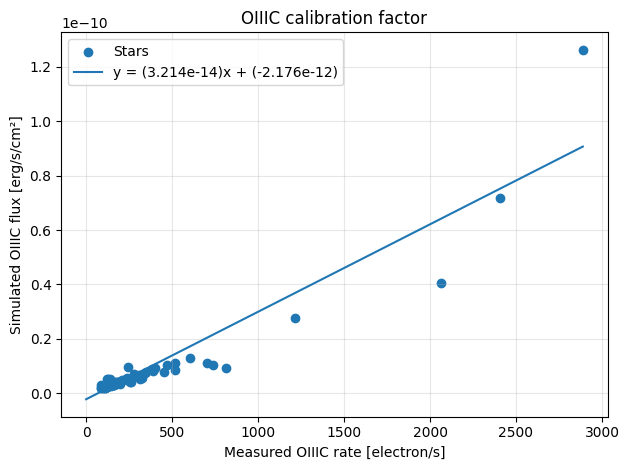

Slope: 3.214e-14
Intercept: -2.176e-12
R²: 0.8775


In [57]:
# (simulated_flux = m * measured_rate + intercept)

x = cal_table["oiiic_rate"].value
y = cal_table["simulated_oiiic_flux"].value

# mask invalid values
mask = (np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0))
x = x[mask]
y = y[mask]

# get line of best fit
m, b = np.polyfit(x, y, 1)

# line of best fit
x_line = np.linspace(0, x.max(), 200)
y_line = m * x_line + b

plt.scatter(x, y, label="Stars")
plt.plot(x_line, y_line, label=(f"y = ({m:.3e})x + ({b:.3e})"))

plt.xlabel("Measured OIIIC rate [electron/s]")
plt.ylabel("Simulated OIIIC flux [erg/s/cm²]")
plt.title("OIIIC calibration factor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# check how linear the relationship is
result = linregress(x, y)
m = result.slope
b = result.intercept
r_squared = result.rvalue**2

print(f"Slope: {m:.3e}")
print(f"Intercept: {b:.3e}")
print(f"R²: {r_squared:.4f}")

In [3]:
# scale factor
m_oiii = 2.890e-14
m_oiiic = 3.214e-14
flux_ratio = 0.39077654992386607

scale = m_oiii / m_oiiic * flux_ratio
scale

0.3513827720223936